In [1]:
import cv2
import pandas as pd 
import matplotlib.pyplot as plt 

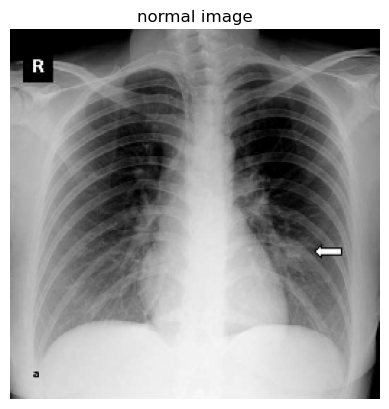

In [5]:
img_dir = 'data/COVID/COVID_2.png'
img = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(img_dir)

plt.imshow(img, cmap='gray')
plt.title('normal image')
plt.axis('off')
plt.show()

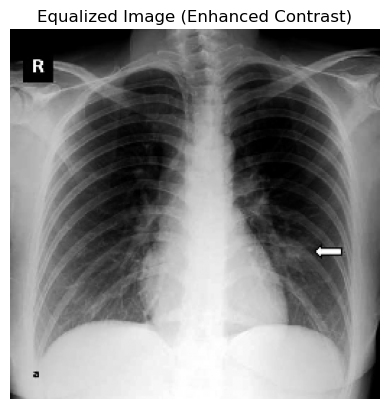

In [6]:
equalized_image = cv2.equalizeHist(img)                    # improve contrast

plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image (Enhanced Contrast)')
plt.axis('off')
plt.show()

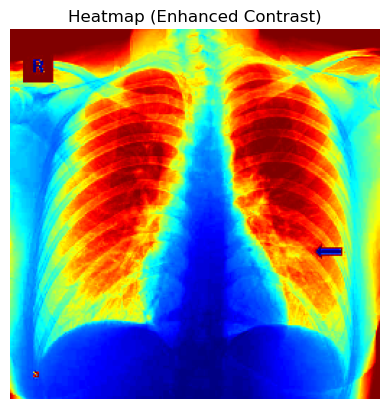

In [ ]:
heatmap = cv2.applyColorMap(equalized_image, cv2.COLORMAP_JET) #color mapping
plt.imshow(heatmap)
plt.title('Heatmap (Enhanced Contrast)')
plt.axis('off')
plt.show()

In [11]:
b, g, r = cv2.split(heatmap)
b = cv2.convertScaleAbs(b, alpha = 1.0, beta = 0)
g = cv2.convertScaleAbs(g, alpha = 1.05, beta = 0)
r = cv2.convertScaleAbs(r, alpha = 0.95, beta = 0)
#alpha = contrast/gain multiplier, beta = brightness/offset multiplier
balanced = cv2.merge([b, g, r])

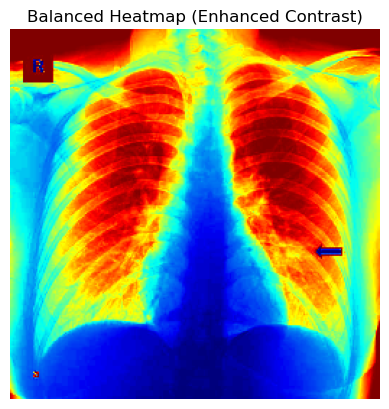

In [12]:
plt.imshow(balanced)
plt.title('Balanced Heatmap (Enhanced Contrast)')
plt.axis('off')
plt.show()

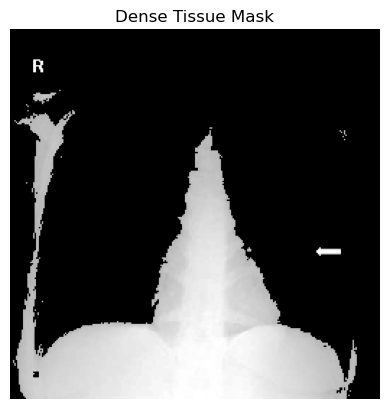

In [23]:
import numpy as np


_, mask = cv2.threshold(
    equalized_image,
    180,
    255,
    cv2.THRESH_BINARY
)

dense_tissue = cv2.bitwise_and(
    equalized_image,
    equalized_image,
    mask=mask
)

plt.imshow(dense_tissue, cmap = 'gray')
plt.title("Dense Tissue Mask")
plt.axis("off")
plt.show()


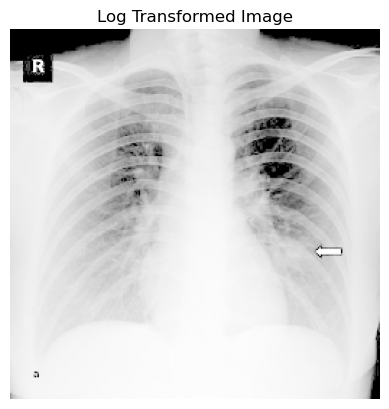

In [24]:
#log transformation - dark vals are expanded more than bright values
#can reveal faint structures in underexposed regions of the X-ray

log_img = np.log1p(img.astype(np.float32))

log_img = cv2.normalize(log_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.imshow(log_img, cmap='gray')
plt.title('Log Transformed Image')
plt.axis('off')
plt.show()

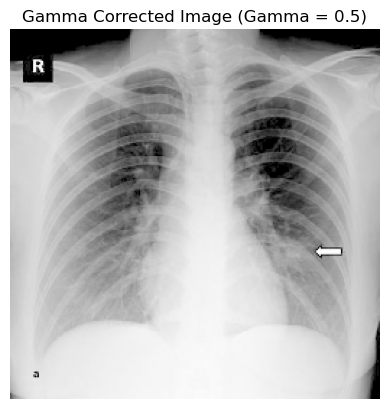

In [25]:
gamma = 0.5
normalized_img = img.astype(np.float32) / 255.0

gamma_img = np.power(normalized_img, gamma)
gamma_img = (gamma_img * 255).astype(np.uint8)

plt.imshow(gamma_img, cmap='gray')
plt.title(f'Gamma Corrected Image (Gamma = {gamma})')
plt.axis('off')
plt.show()